In [68]:
import pandas as pd
path = '/Users/baharehfatemi/Desktop/demokratibasen/Data/eval/gemma-2-9b-checkpoint-9000-inputs-refs-preds-examples_2500.jsonl'

In [77]:
data = pd.read_json(path, lines=True)

KeyboardInterrupt: 

In [70]:
data.columns

Index(['input_text', 'prompt', 'reference', 'prediction'], dtype='object')

420269
4120.8912


<Axes: >

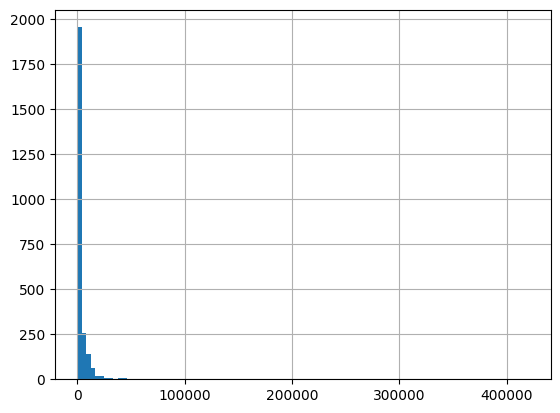

In [71]:
#max length of input_text
print (data['input_text'].str.len().max())

#avg length of input_text
print (data['input_text'].str.len().mean() )

#histogram of input_text length with bins of 100
data['input_text'].str.len().hist(bins=100)




In [72]:
#number of input_text with length greater than 1000
print (data[data['input_text'].str.len() > 50000].shape[0]) 

#drop the input_text with length greater than 50000
data = data[data['input_text'].str.len() <= 50000]



20


<Axes: >

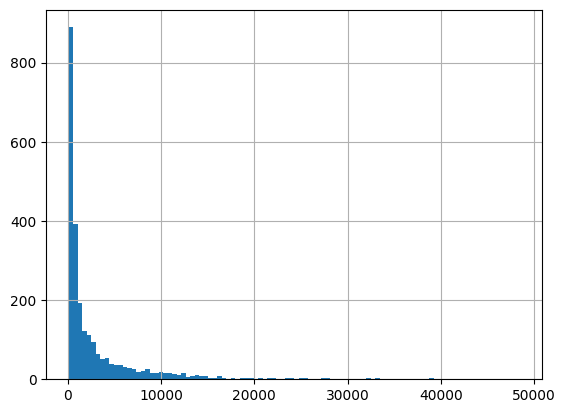

In [73]:
#histogram of input_text length with bins of 100
data['input_text'].str.len().hist(bins=100)

In [74]:
import os
import google.generativeai as genai

API_KEY = os.environ.get("GOOGLE_API_KEY") or os.environ.get("GEMINI_API_KEY")
GEMINI_MODEL = "gemini-2.5-flash"

genai.configure(api_key=API_KEY)
model = genai.GenerativeModel(GEMINI_MODEL)
text = "Hello, how many tokens is this?"
response = model.count_tokens(text)
print(f"Token count: {response.total_tokens}")




Token count: 8


In [75]:
def count_tokens(text):
    response = model.count_tokens(text)
    print(f"Token count: {response.total_tokens}")

count_tokens(data['input_text'][1])

Token count: 9646


In [76]:
import time
import random
from google import genai

client = genai.Client(
    vertexai=True,
    project="your-project-id",
    location="us-central1"
)

def generate_with_retry(prompt, max_retries=5):
    for attempt in range(max_retries):
        try:
            response = client.models.generate_content(
                model="gemini-2.0-flash",
                contents=prompt
            )
            return response.text

        except Exception as e:
            error_str = str(e)

            # Handle 429 (rate limit)
            if "429" in error_str:
                delay = min(2 ** attempt, 8) + random.uniform(0, 0.5)
                print(f"[429] Backing off {delay:.2f}s")

            # Handle 503 (server issue)
            elif "503" in error_str:
                delay = min(2 ** attempt, 20) + random.uniform(0, 1)
                print(f"[503] Retrying in {delay:.2f}s")

            else:
                raise  # real error → don't retry

            time.sleep(delay)

    raise Exception("Max retries exceeded")

AttributeError: module 'google.auth.transport.mtls' has no attribute 'should_use_client_cert'

In [78]:
path = "Data/eval/norwai-mistral-7b-instruct-checkpoint-8000-inputs-refs-preds-examples_2500.jsonl"
import pandas as pd
#read data from path
data = pd.read_json(path, lines=True)

In [81]:
data.iloc[19].prediction

'Figur 1: Utsnitt av plankart som viser eiendomsgrenser og forslag til ny avkjørsel. Figur'

In [80]:
data.columns


Index(['input_text', 'prompt', 'reference', 'prediction'], dtype='object')